In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import json
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import os
import re
from scipy.stats import spearmanr, kruskal
import scikit_posthocs as sp
import warnings
from sklearn.linear_model import LinearRegression
import cellcharter as cc
warnings.filterwarnings('ignore')

/Users/lukashat/miniforge3/envs/cellcharter_scarches/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [3]:
disease = 'disease3'
disease_mapping = adata.obs[[disease, 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)

In [4]:
csv = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_standal/src/downstream/dirSEA/250326COZI_phenotype4_normalized.csv')
csv.rename(columns={'Unnamed: 0': 'image_ID'}, inplace=True)
csv['image_ID'] = csv['image_ID'].replace({'TS-373_IMC42_B_ROI_2.csv': 'TS-373_IMC42_B_002.csv'})
csv['disease3'] = csv['image_ID'].map(disease_mapping['disease3'])
disease_order = ['MM', 'SMM', 'MGUS']
csv[disease] = pd.Categorical(csv[disease], 
                                categories=disease_order, 
                                ordered=True)
csv = csv.sort_values(disease)

In [5]:
targets = ['image_ID', 'CD8+Tcells_Plasma Cells/MM cells', 'CD4+Tcells_Plasma Cells/MM cells', 'Dendritic Cells_Plasma Cells/MM cells', 'activated Macrophages/Monocytes_Plasma Cells/MM cells', 'Neutrophils_Plasma Cells/MM cells',
           'Macrophages/Monocytes_Plasma Cells/MM cells']
pattern = '|'.join(map(re.escape, targets))
interactions = csv.filter(regex=pattern, axis=1)
interactions[disease] = interactions['image_ID'].map(disease_mapping[disease])
interactions[disease] = pd.Categorical(interactions[disease], 
                                categories=disease_order, 
                                ordered=True)
interactions = interactions.sort_values(disease)
interactions = interactions.replace([np.inf, -np.inf], np.nan)

In [6]:
interactions.rename(columns={'CD8+Tcells_Plasma Cells/MM cells': 'CD8 Tcells*PCs','CD4+Tcells_Plasma Cells/MM cells': 'CD4 Tcells*PCs', 'Dendritic Cells_Plasma Cells/MM cells': 'DCs*PCs',
                             'activated Macrophages/Monocytes_Plasma Cells/MM cells': 'HLA-DR+ Macs/monos*PCs', 'Neutrophils_Plasma Cells/MM cells': 'Neutrophils*PCs', 'Macrophages/Monocytes_Plasma Cells/MM cells': 'Macs/monos*PCs'}, inplace=True)
interactions

,image_ID,CD4 Tcells*PCs,CD8 Tcells*PCs,DCs*PCs,Macs/monos*PCs,Neutrophils*PCs,HLA-DR+ Macs/monos*PCs,disease3
0,TS-373_IMC77_B_001.csv,0.026666,0.108408,NaN,0.100689,0.175820,0.114973,MM
7,TS-373_IMC35_B_002.csv,0.034445,0.081197,0.006491,0.109167,0.086356,0.072948,MM
8,TS-373_IMC38_B_001.csv,-0.074097,-0.053526,-0.032461,-0.031050,-0.100721,-0.069406,MM
9,TS-373_IMC90.1_B_001.csv,-0.046553,-0.043821,-0.039406,-0.035886,-0.330908,0.003570,MM
10,TS-373_IMC56_B_001.csv,-0.034829,-0.098023,0.000268,-0.037690,-0.102854,-0.046146,MM
...,...,...,...,...,...,...,...,...
97,TS-373_IMC82_MGUS_002.csv,0.030952,0.057040,-0.009923,0.012615,0.057370,0.089195,MGUS
49,TS-373_IMC02_MGUS_001.csv,0.013602,0.049994,0.026209,0.033117,0.125424,0.065531,MGUS
15,TS-373_IMC04_MGUS_001.csv,0.036873,0.028668,0.036007,-0.011365,0.045641,0.022336,MGUS
14,TS-373_IMC03_MGUS_001.csv,-0.012705,0.063379,0.003028,0.023786,0.010532,-0.006998,MGUS


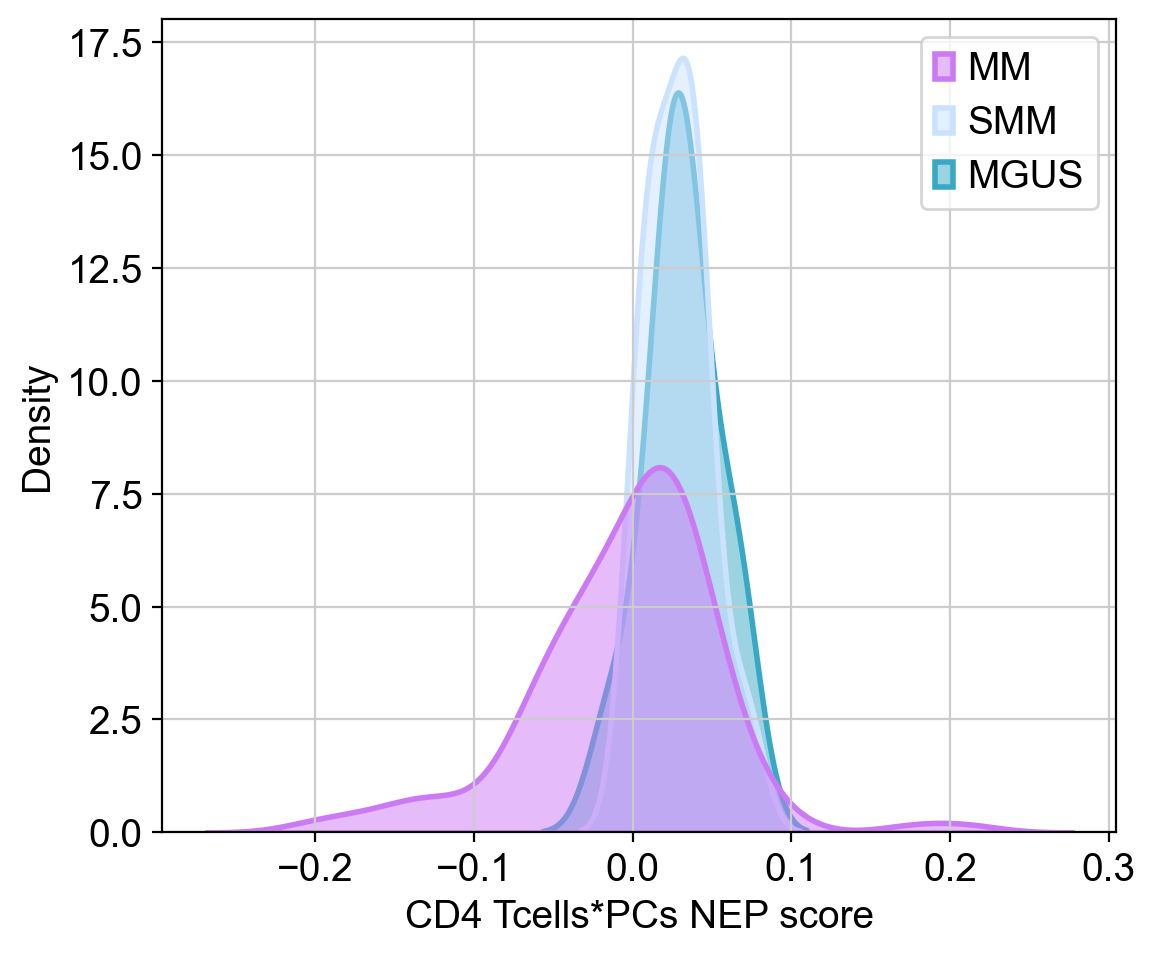

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
target = 'CD4 Tcells*PCs'
sns.kdeplot(data=interactions, x=target, hue=disease, palette=disease3_color_map, fill=True, alpha=0.5, linewidth=2, common_norm=False, ax=ax)
ax.set_xlabel(f'{target} NEP score', fontsize=14)
ax.set_ylabel('Density', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
legend = ax.get_legend()
legend.set_title('')
for text in legend.get_texts():
	text.set_fontsize(14)
fig.tight_layout()

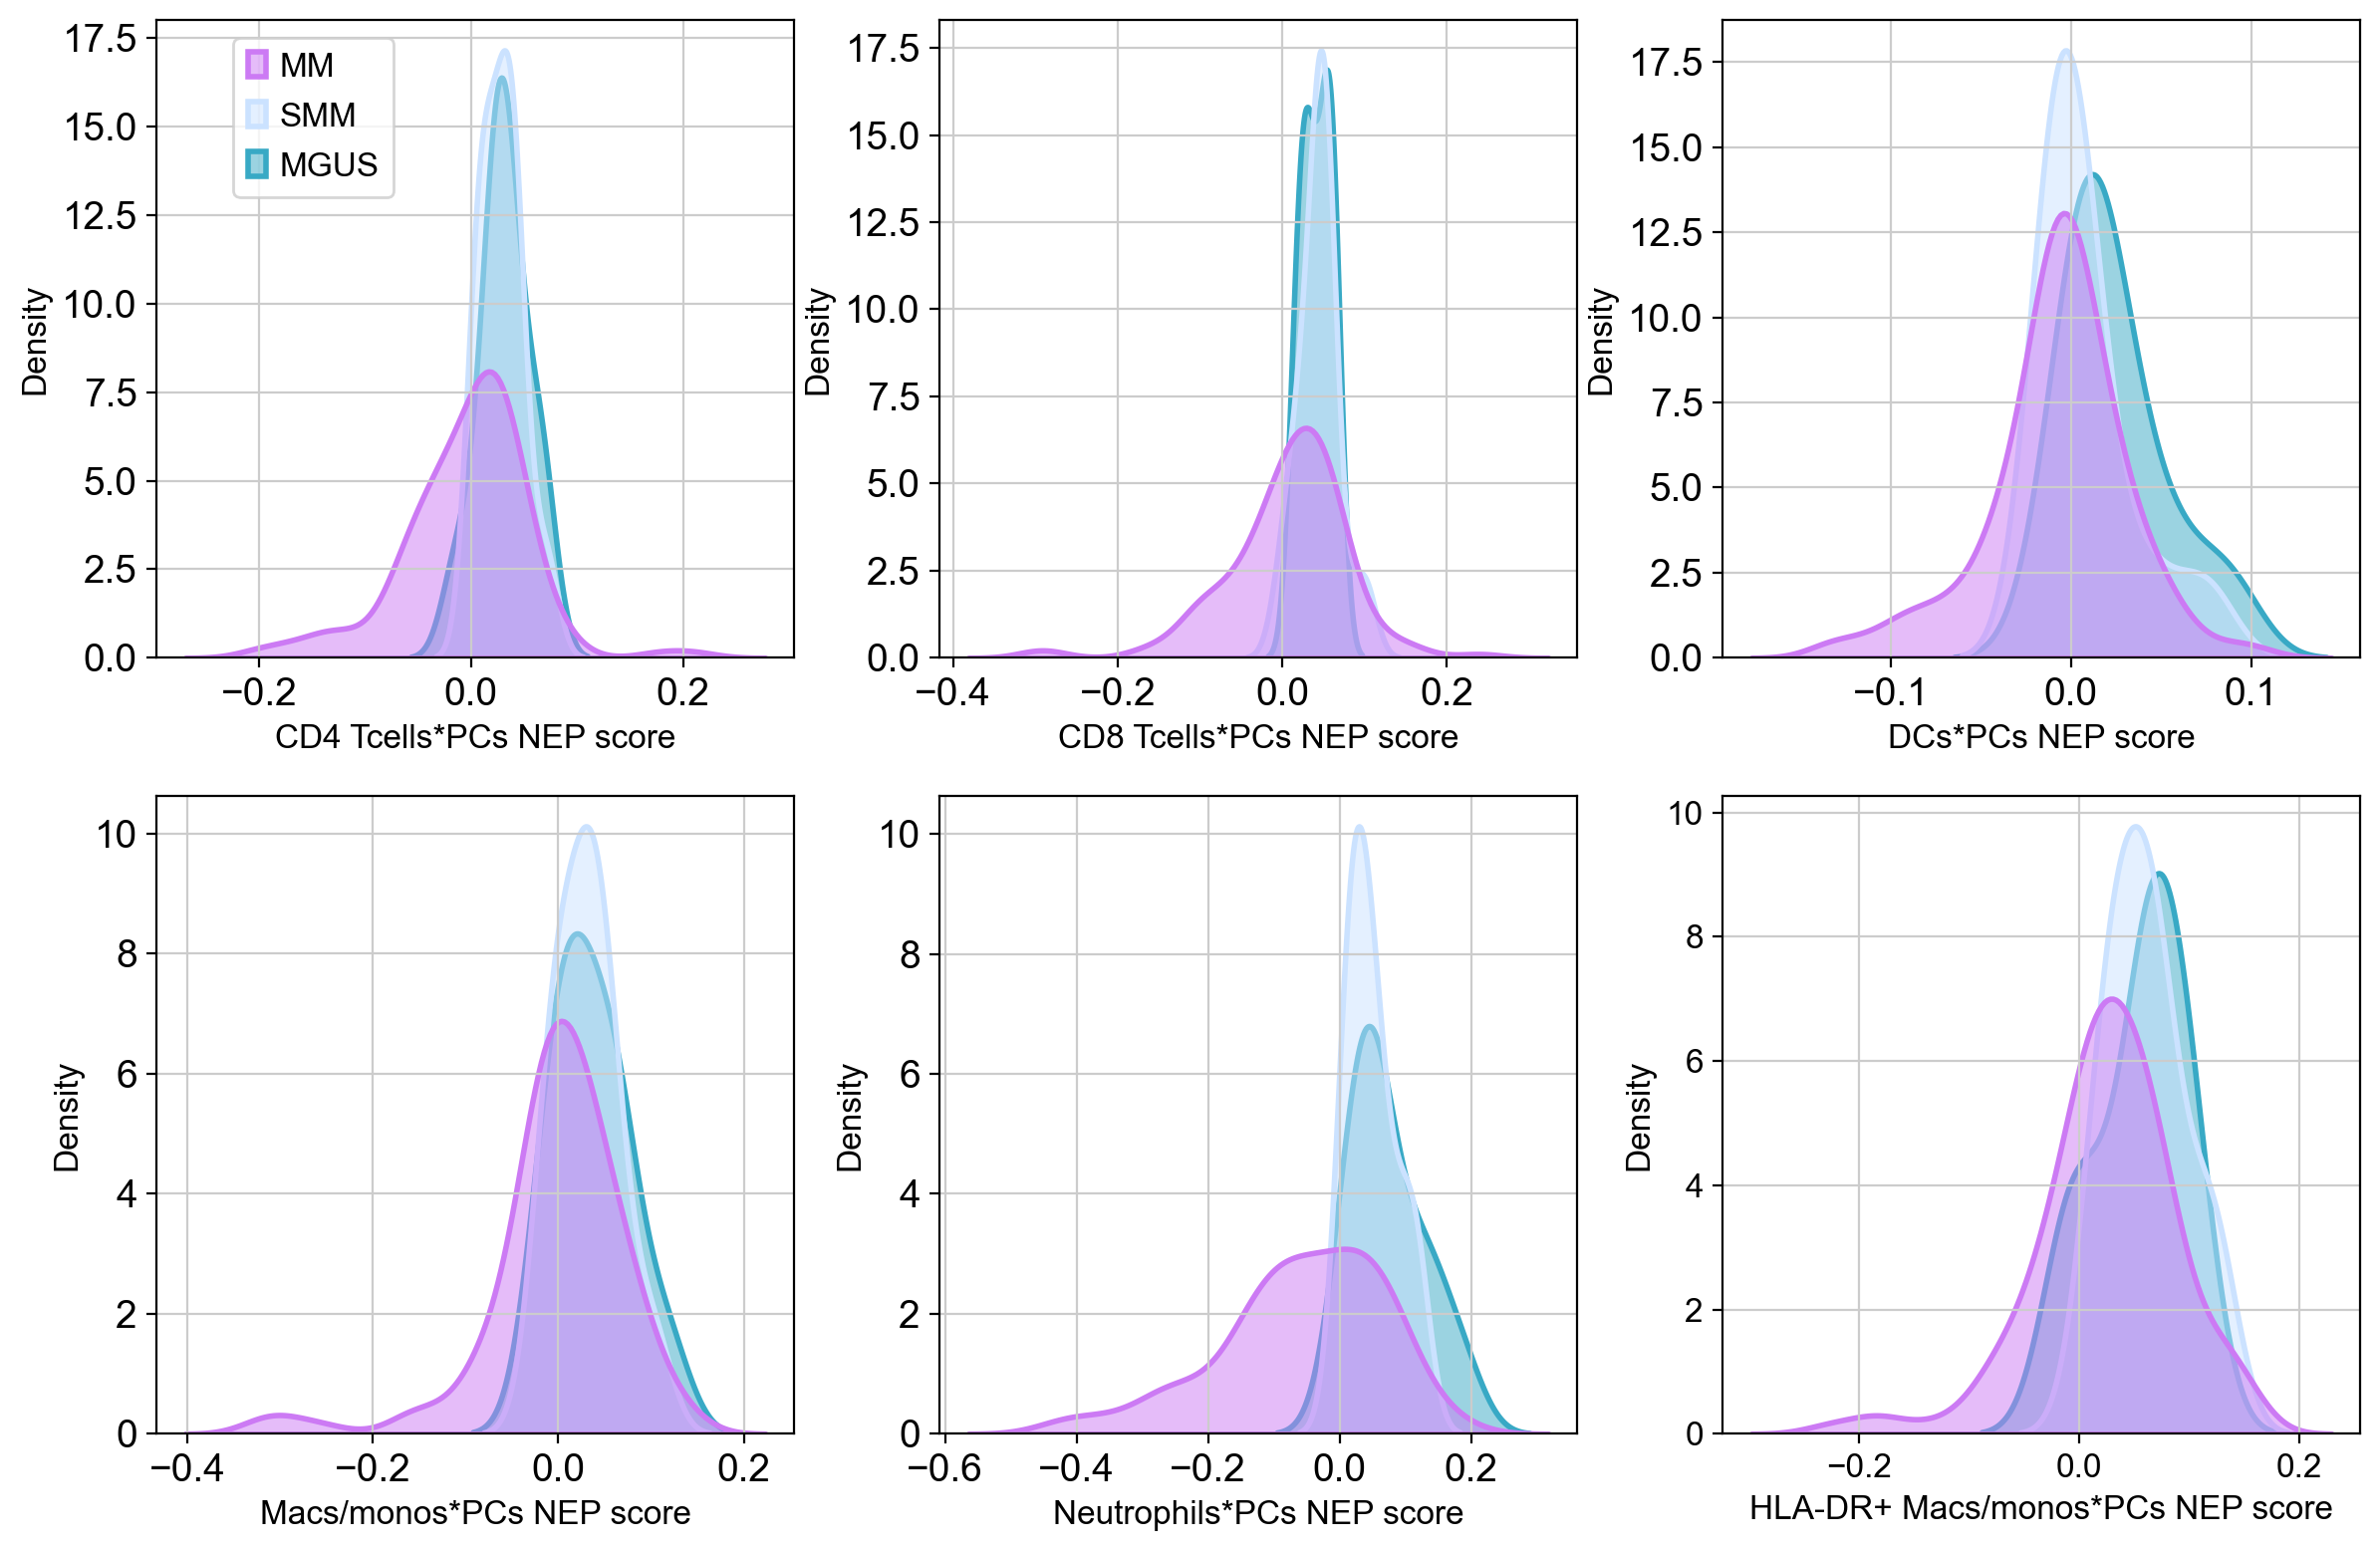

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i, target in enumerate(interactions.columns[1:-1]):
    sns.kdeplot(data=interactions, x=target, hue=disease, palette=disease3_color_map, fill=True, alpha=0.5, linewidth=2, common_norm=False, ax=ax[i//3, i%3])
    ax[i//3, i%3].set_xlabel(f'{target} NEP score', fontsize=12)
    ax[i//3, i%3].set_ylabel('Density', fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    legend = ax[i//3, i%3].get_legend()
    legend.set_title('')
    if i==0:
        for text in legend.get_texts():
            text.set_fontsize(12)
        legend.set_bbox_to_anchor((0.4, 1))
    else:
        legend.remove()

fig.tight_layout()
fig.savefig(os.path.join(save_path_supp, f"nep_immune_seperated_kde.{extension}"), bbox_inches='tight')

In [9]:
adata_cc = adata.copy()
cc.gr.connected_components(adata_cc, cluster_key='cellcharter_CN', min_cells=1)
adata_cc = adata_cc[~adata_cc.obs['component'].isna()]
count = adata_cc.obs['component'].value_counts().to_dict()

if 'shape_component' not in adata_cc.uns:
    adata_cc.uns['shape_component'] = {}
adata_cc.uns['shape_component']['count'] = count
df = pd.DataFrame(adata_cc.uns['shape_component']['count'].items(), columns=['component', 'count'])
df = pd.merge(df, adata_cc.obs[['component', 'image_ID']].drop_duplicates().dropna(), on='component')
df = pd.merge(df, adata_cc.obs[['component', 'cellcharter_CN']].drop_duplicates().dropna(), on='component')
df = pd.merge(df, adata_cc.obs[['component', 'disease3']].drop_duplicates().dropna(), on='component')

counts = adata_cc[~adata_cc.obs['component'].isna()].obs.groupby(['image_ID', 'cellcharter_CN']).size().reset_index(name='total_neighborhood_cells_image')
df = df.merge(counts, on=['image_ID', 'cellcharter_CN'], how='left')

unique_counts = (
    adata_cc.obs.groupby(["image_ID", "cellcharter_CN"])["component"]
    .nunique()
    .reset_index()
    .rename(columns={"component": "unique_components_neighborhood_image"})
)
df = df.merge(unique_counts, on=["image_ID", "cellcharter_CN"], how="left")
df = df[df['cellcharter_CN'] =='PC_OXPHOS']
df2 = df.groupby('image_ID').max('count')

In [10]:
merged = pd.merge(
    interactions,
    df2,
    left_on='image_ID',
    right_on='image_ID')
merged.dropna(inplace=True)
merged['count'] = np.log(merged['count'])
merged

,image_ID,CD4 Tcells*PCs,CD8 Tcells*PCs,DCs*PCs,Macs/monos*PCs,Neutrophils*PCs,HLA-DR+ Macs/monos*PCs,disease3,count,total_neighborhood_cells_image,unique_components_neighborhood_image
1,TS-373_IMC35_B_002.csv,0.034445,0.081197,0.006491,0.109167,0.086356,0.072948,MM,2.484907,43.0,21.0
2,TS-373_IMC38_B_001.csv,-0.074097,-0.053526,-0.032461,-0.031050,-0.100721,-0.069406,MM,5.010635,865.0,109.0
3,TS-373_IMC90.1_B_001.csv,-0.046553,-0.043821,-0.039406,-0.035886,-0.330908,0.003570,MM,6.182085,1305.0,71.0
4,TS-373_IMC56_B_001.csv,-0.034829,-0.098023,0.000268,-0.037690,-0.102854,-0.046146,MM,5.043425,857.0,103.0
5,TS-373_IMC92_B_002.csv,0.085532,0.085573,0.055504,0.020517,0.095705,0.087468,MM,3.688879,131.0,44.0
...,...,...,...,...,...,...,...,...,...,...,...
147,TS-373_IMC82_MGUS_002.csv,0.030952,0.057040,-0.009923,0.012615,0.057370,0.089195,MGUS,3.526361,106.0,49.0
148,TS-373_IMC02_MGUS_001.csv,0.013602,0.049994,0.026209,0.033117,0.125424,0.065531,MGUS,2.639057,114.0,60.0
149,TS-373_IMC04_MGUS_001.csv,0.036873,0.028668,0.036007,-0.011365,0.045641,0.022336,MGUS,2.302585,184.0,103.0
150,TS-373_IMC03_MGUS_001.csv,-0.012705,0.063379,0.003028,0.023786,0.010532,-0.006998,MGUS,4.369448,160.0,33.0


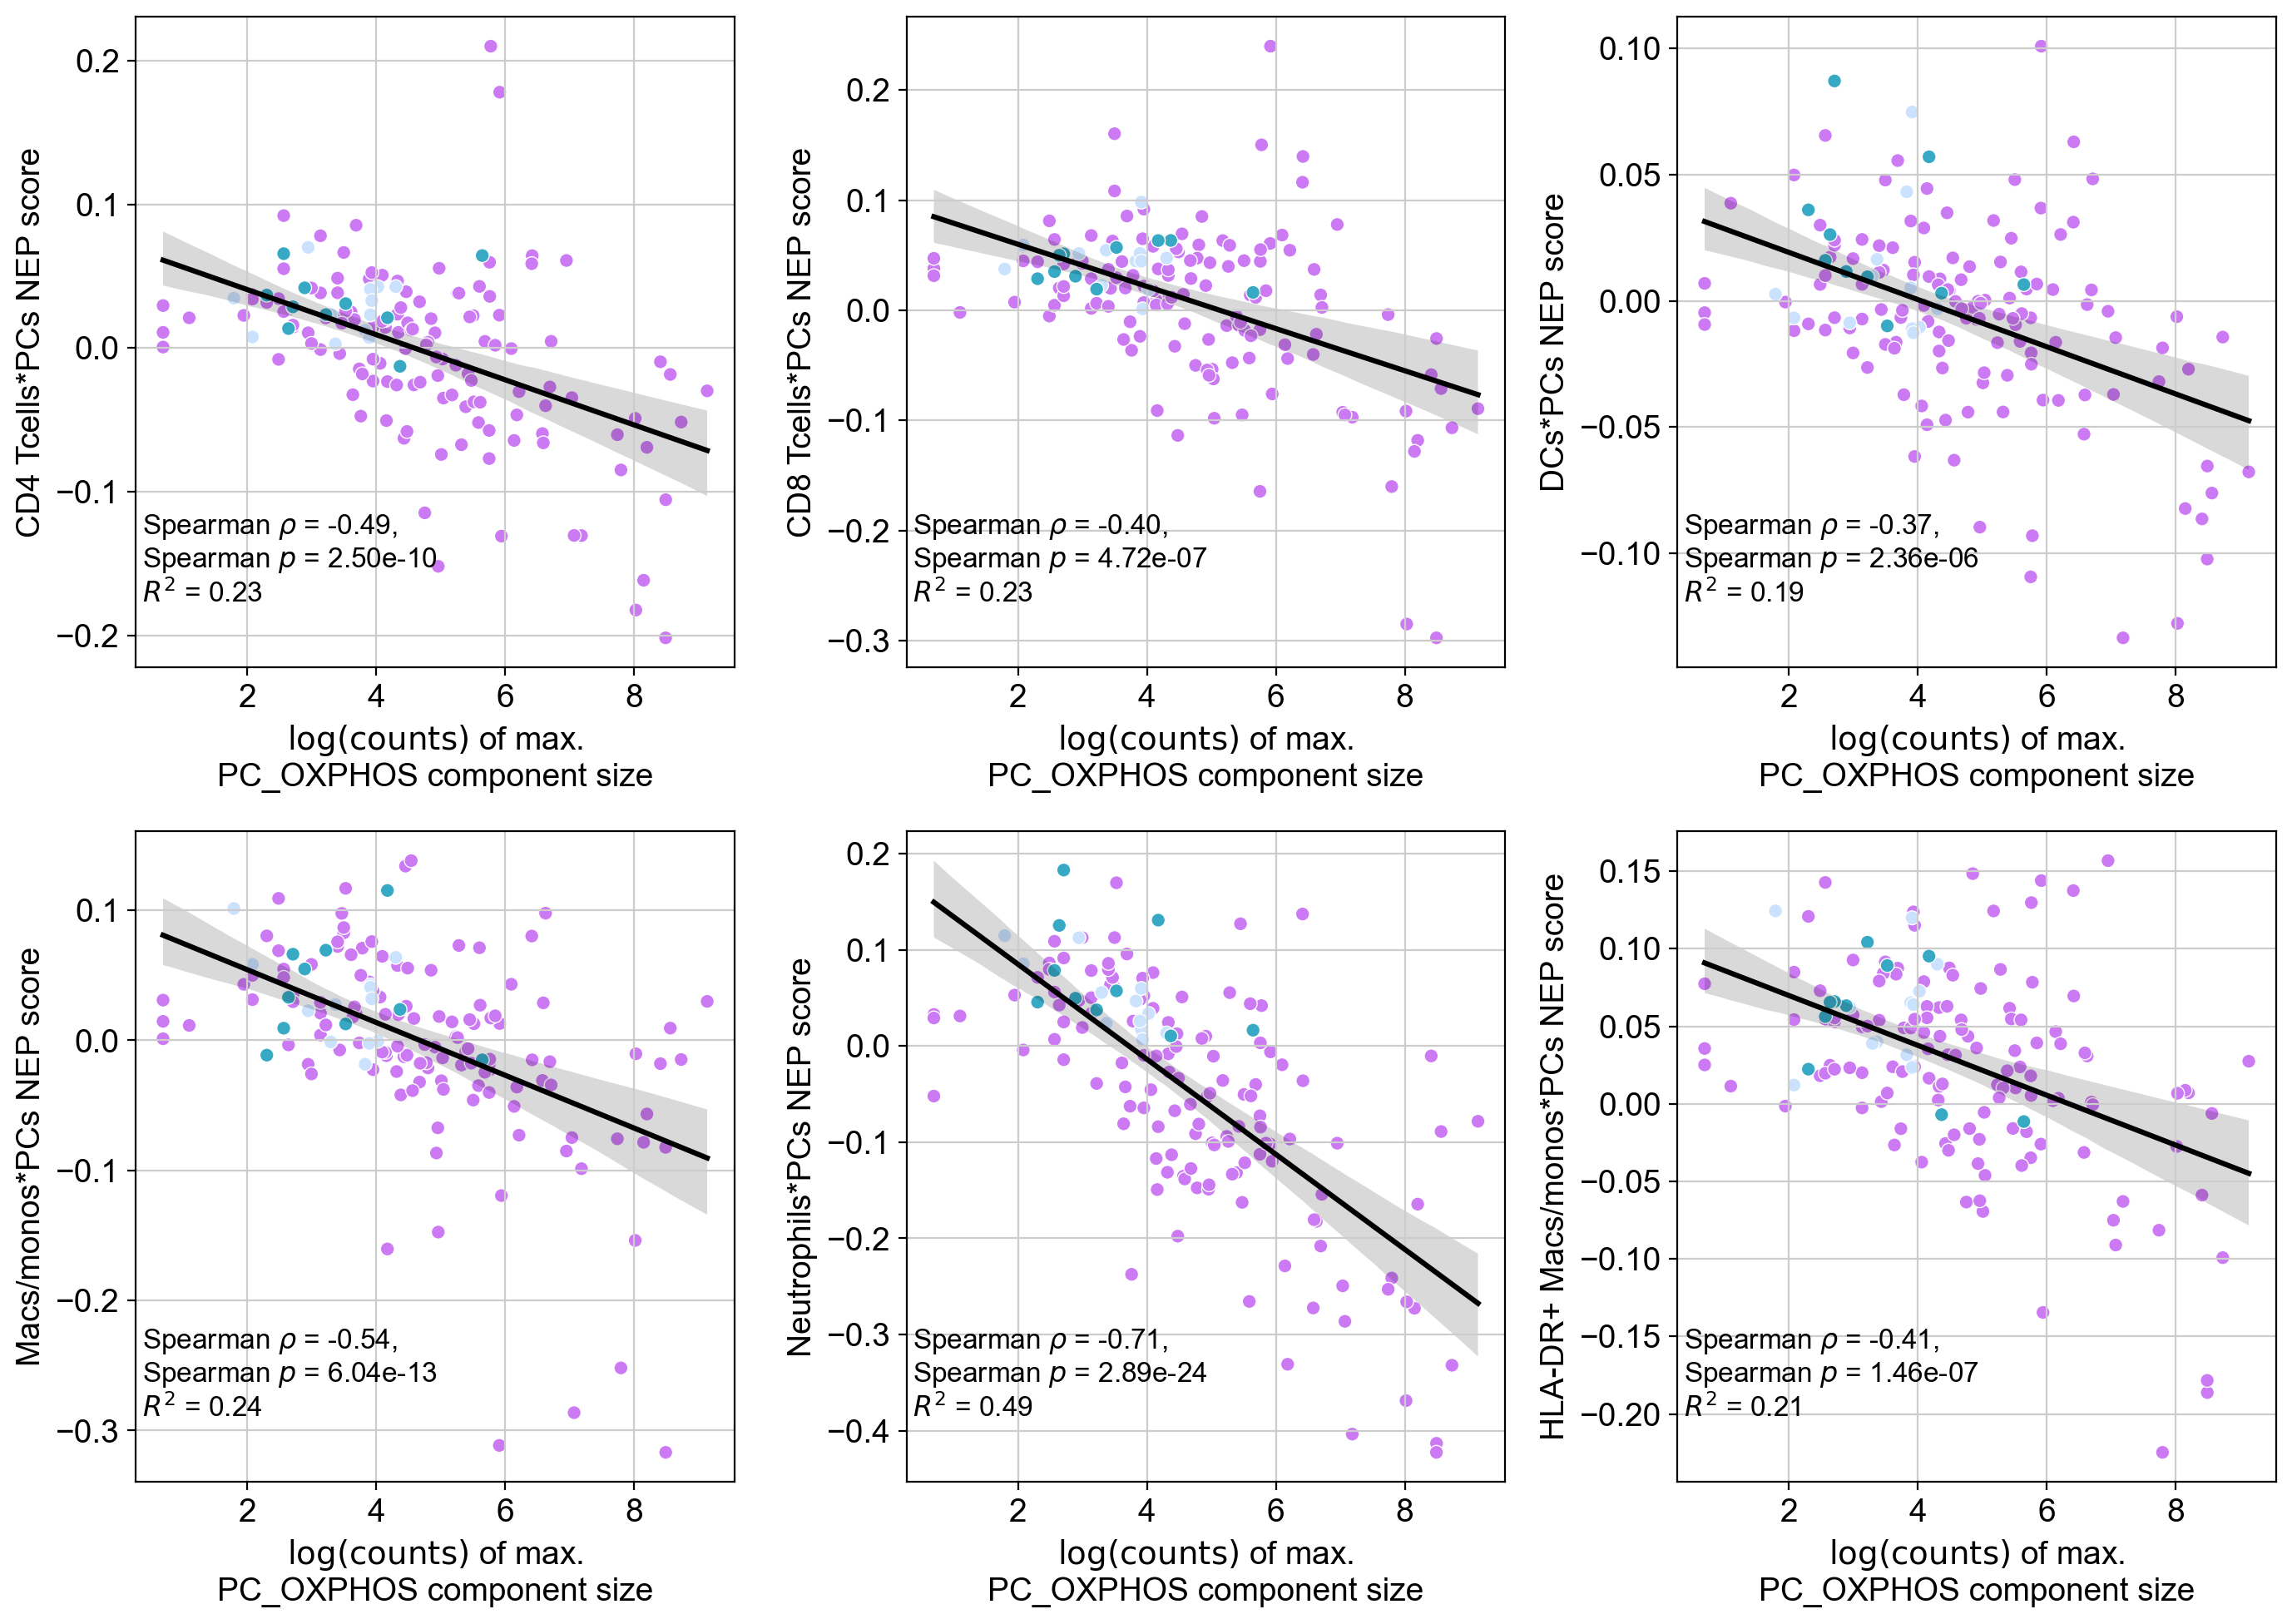

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(14, 10))
for i, target in enumerate(merged.columns[1:7]):
    sns.scatterplot(
    x='count',
    y=target,
    data=merged,
    hue='disease3',
    palette=disease3_color_map,
    legend=False,
    ax=ax[i//3, i%3])
    sns.regplot(
        x='count',
        y=target,
        data=merged,
        scatter=False,
        color='black',
        ax=ax[i//3, i%3]
    )
    # Select 'count' as a DataFrame (2D)
    X = merged[['count']]
    y = merged[target]

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = model.score(X, y)
    stat, p = spearmanr(merged['count'], merged[target])
    ax[i//3, i%3].text(0.01, 0.1, f'Spearman $\\rho$ = {stat:.2f}, \nSpearman $p$ = {p:.2e} \n$R^2$ = {r2:.2f}', transform=ax[i//3, i%3].transAxes, fontsize=12)
    ax[i//3, i%3].set_xlabel(r'$\log(\text{counts})$ of max.' + '\n' + r'PC_OXPHOS component size', fontsize=14)
    ax[i//3, i%3].set_ylabel(f'{target} NEP score', fontsize=14)


fig.tight_layout()
fig.savefig(os.path.join(save_path_supp, f"nep_immune_Seperated_correlation.{extension}"), bbox_inches='tight')